<a href="https://www.kaggle.com/code/victoramachree/correlation-and-prediction?scriptVersionId=153186818" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Correlation


In [1]:
#Importing Libraries
import pandas as pd
import numpy as np 
import pandas as pd 
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df=pd.read_csv('/kaggle/input/sleep-health-and-lifestyle-dataset/Sleep_health_and_lifestyle_dataset.csv')

In [3]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [5]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [6]:
df2= df[['Sleep Duration','Quality of Sleep', 'Physical Activity Level','Stress Level','Heart Rate','Daily Steps']]

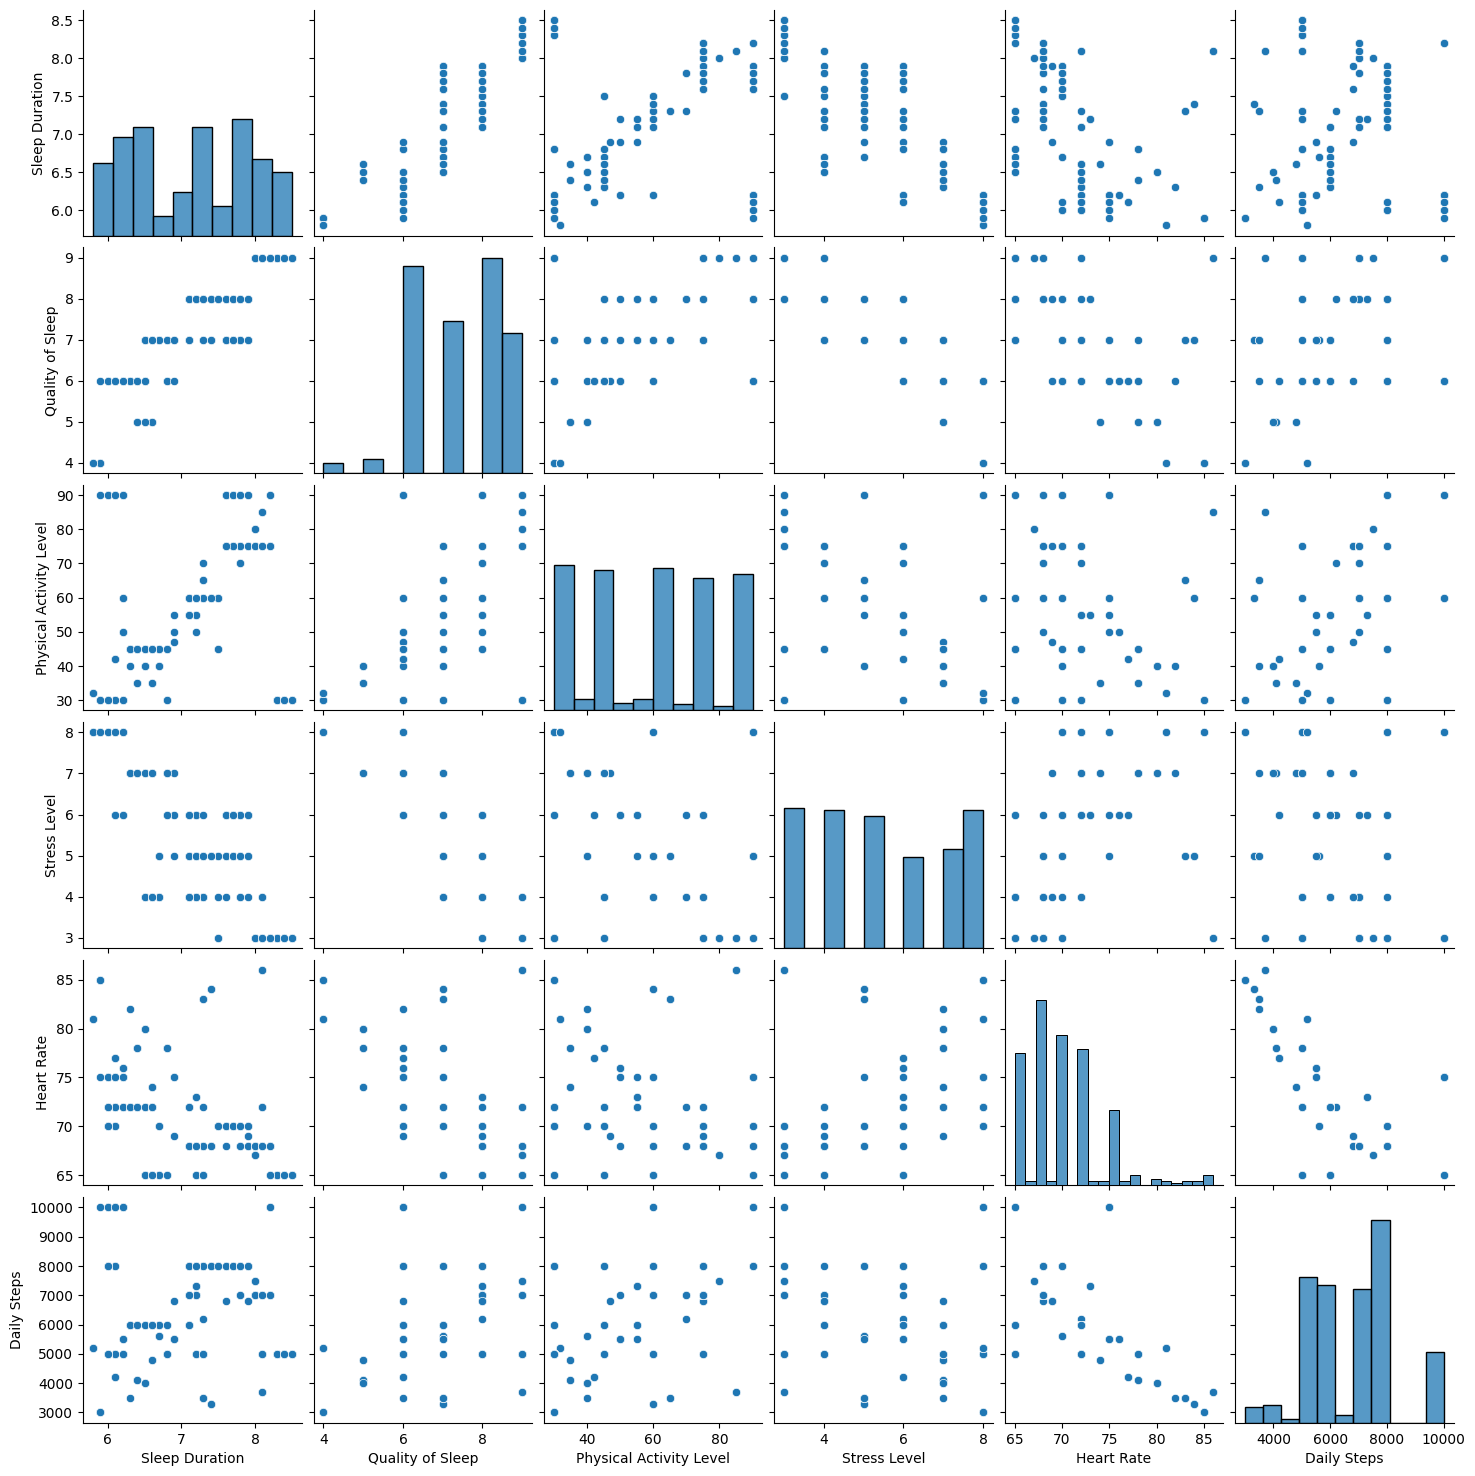

In [7]:
sns.pairplot(df2)

In [8]:
df2.corr()

,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
Sleep Duration,1.000000,0.883213,0.212360,-0.811023,-0.516455,-0.039533
Quality of Sleep,0.883213,1.000000,0.192896,-0.898752,-0.659865,0.016791
Physical Activity Level,0.212360,0.192896,1.000000,-0.034134,0.136971,0.772723
Stress Level,-0.811023,-0.898752,-0.034134,1.000000,0.670026,0.186829
Heart Rate,-0.516455,-0.659865,0.136971,0.670026,1.000000,-0.030309
Daily Steps,-0.039533,0.016791,0.772723,0.186829,-0.030309,1.000000


<Axes: >

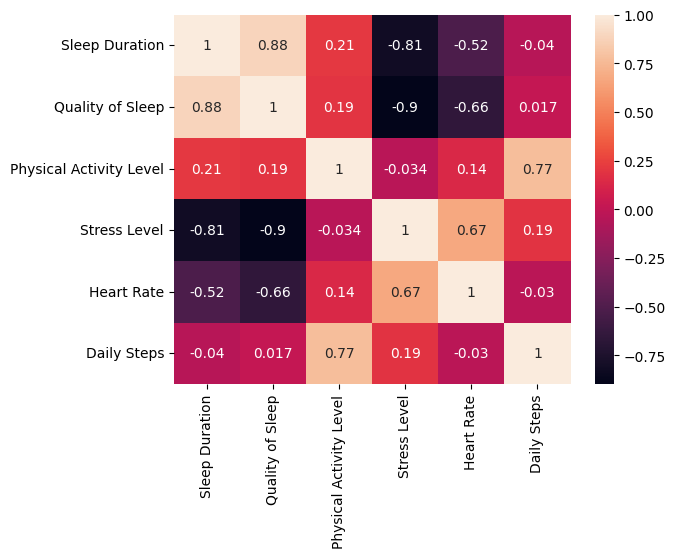

In [9]:
correlation_matrix= df2.corr(method='pearson')

sns.heatmap(correlation_matrix, annot=True)

**positive correlation - (1 or close to 1)**

**negative correlation - (-1 0r close to -1)**

Text(0.5, 1.0, 'Sleep Duration VS Quality Of Sleep')

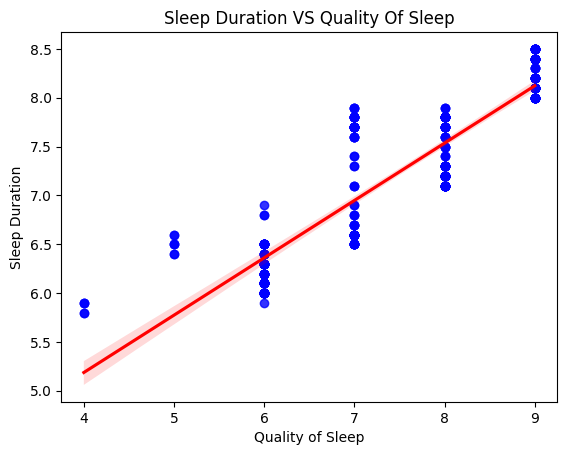

In [10]:
#high positive correlation between Sleep duration and Quality Of Sleep
sns.regplot(x='Quality of Sleep',y='Sleep Duration',data=df2,scatter_kws={'color':'blue'},line_kws={'color':'red'})
plt.title('Sleep Duration VS Quality Of Sleep')

Text(0.5, 1.0, 'Stress Level VS Quality Of Sleep')

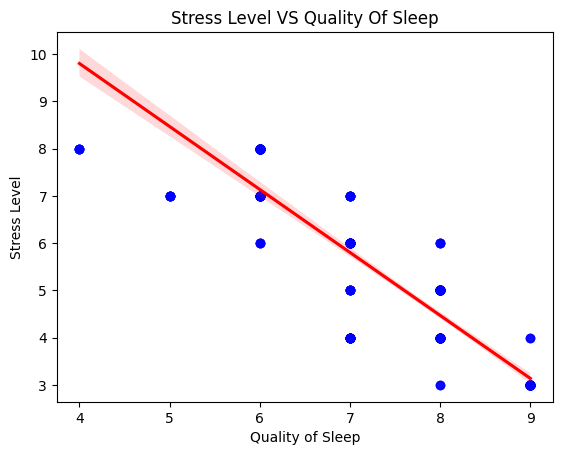

In [11]:
#high negative correlation between Stress level and Quality of Sleep.
sns.regplot(x='Quality of Sleep',y='Stress Level',data=df2,scatter_kws={'color':'blue'},line_kws={'color':'red'})
plt.title('Stress Level VS Quality Of Sleep')

Text(0.5, 1.0, 'Stress Level VS Sleep Duration')

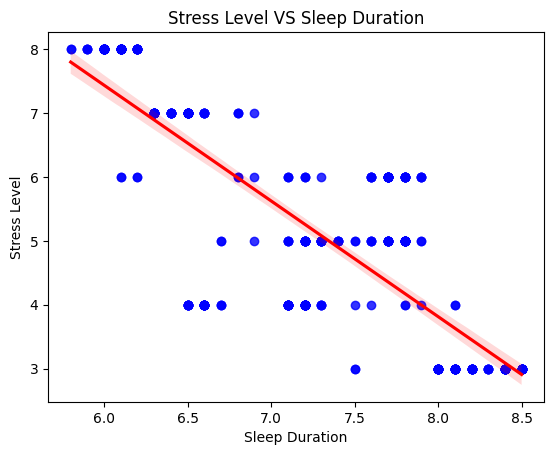

In [12]:
#High negative correlation between Stress Level and Sleep duration.
sns.regplot(x='Sleep Duration',y='Stress Level',data=df2,scatter_kws={'color':'blue'},line_kws={'color':'red'})
plt.title('Stress Level VS Sleep Duration')

In [13]:
#Rename Columns.

newdf2= df2.rename(columns={"Sleep Duration":"Sleep_Duration","Physical Activity Level":"Physical_Activity_Level","Heart Rate":"Heart_Rate","Daily Steps":"Daily_Steps", "Quality of Sleep":"Quality_of_Sleep", "Stress Level":"Stress_Level"})


# Modeling

In [14]:
x= newdf2[['Quality_of_Sleep','Sleep_Duration']]
y=newdf2[['Stress_Level']]

x_train, x_test, y_train, y_test= train_test_split(x, y,test_size=0.3, random_state=42)

In [15]:
#OLS METHOD.
ols_data=pd.concat([x_train, y_train], axis =1)
ols_formula= "Stress_Level ~ Quality_of_Sleep + Sleep_Duration"


OLS = ols(formula = ols_formula, data = ols_data)



model=OLS.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Stress_Level   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     489.1
Date:                Fri, 01 Dec 2023   Prob (F-statistic):           1.65e-88
Time:                        15:05:13   Log-Likelihood:                -312.37
No. Observations:                 261   AIC:                             630.7
Df Residuals:                     258   BIC:                             641.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           15.3484      0.496     30.958      0.000      14.372      16.325
Quality_of_Sleep    -1.2875      0.089    -14.410      0.000      -1.463      -1.112
Sleep_Duration      -0.0789      0.134     -0.589      0.557      -0.343       0.185
==============================================================================
Omnibus:                       24.284   Durbin-Watson:                   2.075
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               28.746
Skew:                          -0.809   Prob(JB):                     5.73e-07
Kurtosis:                       3.149   Cond. No.                         106.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [16]:
ml=LinearRegression()
ml.fit(x_train,y_train)

#Training model for prediction
y_predict=ml.predict(x_train)

In [17]:
from sklearn.metrics import r2_score
r2_score(y_train, y_predict)

0.7912997569883011

In [18]:
#Predicting Stress level for Quality Of Sleep of 6.6 and Sleep Duration of 5.
ml.predict([[5,6.1]])

/opt/conda/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[8.42963506]])

In [19]:
ml.predict([[9,8]])

/opt/conda/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[3.12975365]])

# summary

**from the data there's positive correlation between sleep duration and quality of sleep and negative correlation between stress level against quality of sleep and sleep duration.**


**prediction model has an r2 of 0.79 and can account for 79% variance.**

**with more data and analysis, prediction model can be improved**
